# Sampling in Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing the dataset
coffee_df = pd.read_feather('./datasets/coffee_ratings_full.feather')
coffee_df.head()

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0.0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2.0,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


## Sampling using the `df.sample()` method

In [3]:
# Creating a subset from the coffee_df 
points_flvr_pop = coffee_df[["total_cup_points", "flavor"]]

# Creating a sample - selecting 10 randowm rows from above df
points_flvr_smpl = points_flvr_pop.sample(n=10)
print(points_flvr_smpl)

      total_cup_points  flavor
90               85.08    8.00
144              84.58    7.75
664              82.50    7.50
754              82.25    7.58
797              82.00    7.33
779              82.08    7.58
866              81.75    7.42
1267             76.17    7.33
31               86.50    8.17
835              81.83    7.50


Notice the rowIDs of the randomly selected rows.

## Population parameters & Sample statistics
- Population parameters - a calculation made on the population dataset
- Point estimate / sample stat - a calculation made on the sample dataset

In [4]:
# Population stats for flavors
print("Stats for 'flavor' column :")
print(f"Population mean - {coffee_df["flavor"].mean().round(2)}")
print(f"Sample mean - {points_flvr_smpl["flavor"].mean().round(2)}")

Stats for 'flavor' column :
Population mean - 7.53
Sample mean - 7.62


Note that sample mean is similar BUT NOT identical to population mean.

## Convenience sampling
It is basically collecting data using the easiest method -- can result in samples that aren't representative of the population. 

Equivalently, this means findings from the sample are **not generalizable to the population**. 

**EXAMPLE:**<br>
Sampling only the first 10 rows of a dataset instead of the entire dataset. Here, each row in the sample df will not be an appropriate representation of the overal population dataset -- this will introduce _sample bias_.



In [5]:
print(f"Population mean of points - {coffee_df["total_cup_points"].mean().round(2)}")

print(f"Sample mean of points for first 10 rows - {coffee_df["total_cup_points"].head().mean()}")

Population mean of points - 82.15
Sample mean of points for first 10 rows - 89.616


Thus, there was significant difference between the actual population mean than that of the sample mean. this is called **sample bias**.

### Visualizing Convenience bias
Visualizing the distributions of the population (entire dataset) and the sample(first 10 rows) can help determine whether or not the sample is representative of the population.

In [6]:
coffee_df["total_cup_points"].describe()

count    1338.000000
mean       82.151203
std         2.686862
min        59.830000
25%        81.102500
50%        82.500000
75%        83.670000
max        90.580000
Name: total_cup_points, dtype: float64

_From above stats of the `total_cup_points` column, Lets consider bins range form 59 - 92_

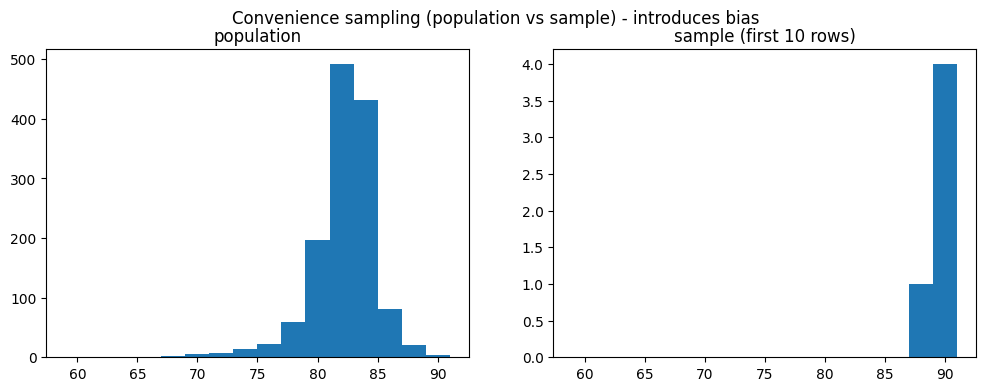

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.hist(data = coffee_df , x="total_cup_points" , bins=np.arange(59,92,2))
ax1.set_title("population")

ax2.hist(data = coffee_df.head() , x="total_cup_points", bins=np.arange(59,92,2))
ax2.set_title("sample (first 10 rows)")

fig.suptitle("Convenience sampling (population vs sample) - introduces bias")
plt.show()

We can see how skewed the distribution was for the sample data , hence the large mean value.

>This can be resolved by taking _n_ random values from the entire population dataset -- this will closely resemble the overall population dataset.

### Visualizing random sample bias

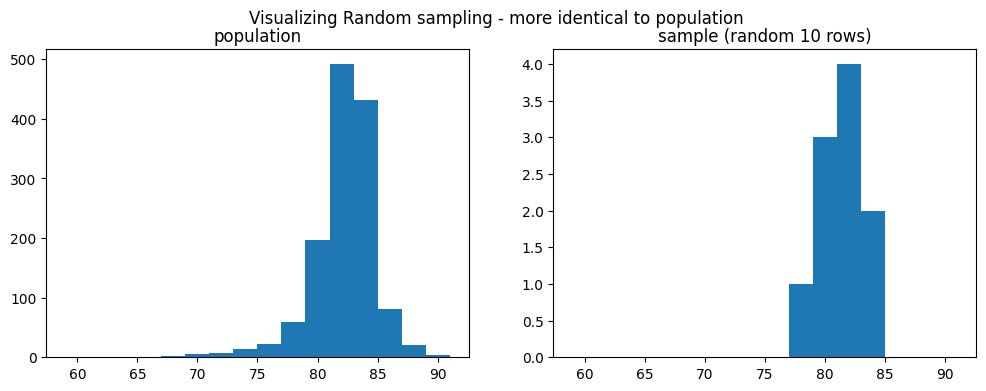

In [8]:
# Creating a sample of 10 random rows from the population
coffee_smpl = coffee_df.sample(n=10)

# Plotting distribution of ratings for population & sample 
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.hist(data = coffee_df , x="total_cup_points" , bins=np.arange(59,92,2))
ax1.set_title("population")

ax2.hist(data = coffee_smpl , x="total_cup_points", bins=np.arange(59,92,2))
ax2.set_title("sample (random 10 rows)")

fig.suptitle("Visualizing Random sampling - more identical to population")
plt.show()

### Pseudo-random Number generation

The first random no. is called 'seed value'. The next subsequent 'random' no. is generated from its previous 'random' no. The primary reasons for setting a seed include:<br>
- Reproducibility: the most common use case. By using the same seed, you and **others can recreate the exact same results**. This is essential for scientific research, where findings must be independently verifiable.

- Debugging and Testing: When a bug occurs during a random process (like a simulation), a fixed seed allows developers to run the code again under the exact same conditions to identify the error.

- Machine Learning Consistency: Seeds are used to ensure that data splitting (training/test sets), weight initialization, and shuffling remain identical across multiple runs. This allows for fair comparisons when testing different model architectures or hyperparameters.

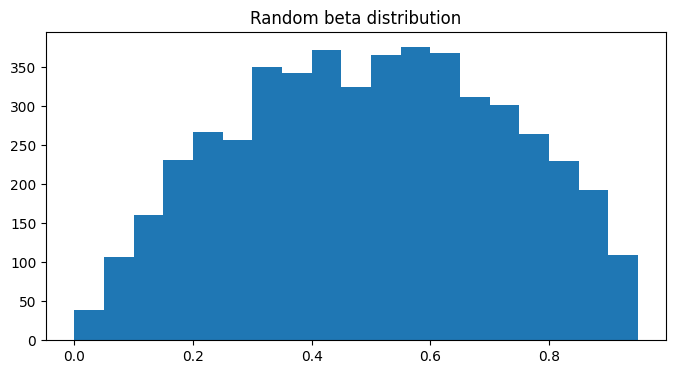

In [9]:
import random
# Setting the initial seed value - this will make the 'random' values reproducible
np.random.seed(1)
random_sample = np.random.beta(a=2, b=2, size=5000)
plt.figure(figsize=(8,4))
plt.hist(random_sample, bins = np.arange(0,1,0.05))
plt.title("Random beta distribution")
plt.show()

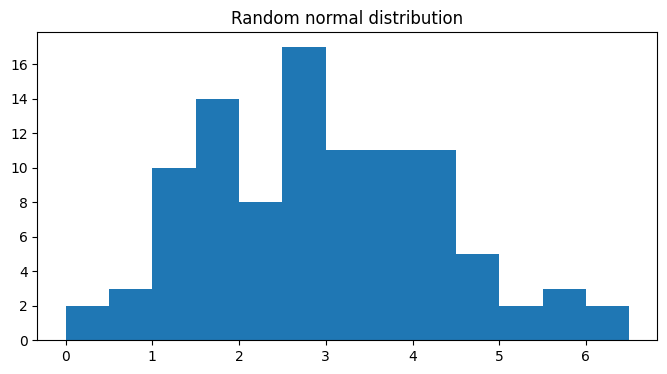

In [10]:
# a random normal distribution with 
random_normal_smple = np.random.normal(loc= 3, scale=1.5, size= 100)
plt.figure(figsize=(8,4))
plt.hist(random_normal_smple, bins=np.arange(0,7,0.5))
plt.title("Random normal distribution")
plt.show()

## Simple Random Sampling
Each row of the population has an equal chance of being seleted. This method is ideal for a quick, unbiased sampling. 

However this does NOT guarantee the winners will represent the whole crowd fairly.

The drawbacks of SRS:
1. **Risk of Underrepresentation (The "Small Group" Problem)** : If your dataset contains a small but important minority group, SRS might miss them entirely or pick so few that they aren't statistically significant.
2. **High Variance in Results** : Because SRS relies entirely on chance, two different random samples from the same population can yield wildly different results (high sampling error), especially with smaller sample sizes.

Hence other sampling methods such as Systematic / Stratified samping are used to sampel the population dataset.

## Systematic sampling
Data is selected using a regular pattern, such as choosing every $n^{th}$ item. It is a quick method but can be affected by hidden patterns (like periodic bias).

In [11]:
# defining sample
sample_size = 5
pop_size = len(coffee_df)
pop_size
# Calculating the interval -- absolute int 
interval = pop_size//sample_size
interval

267

The resulting sample is a slice of every $267^{th}$ row of the population dataset:

In [12]:
# Dividing the dataset based on ontervals
coffee_df.iloc[::interval]

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
267,83.92,Arabica,federacion nacional de cafeteros,Colombia,NaN,NaN,NaN,01-1969,federacion nacional de cafeteros,NaN,...,None,1.0,"March 11th, 2016",Almacafé,e493c36c2d076bf273064f7ac23ad562af257a25,70d3c0c26f89e00fdae6fb39ff54f0d2eb1c38ab,m,NaN,NaN,NaN
534,82.92,Arabica,consejo salvadoreño del café,El Salvador,santa josefita,1-198,beneficio cuzcachapa,09-030-273,soc. coop. cuzcachapa de r.l.,1350,...,Green,1.0,"August 28th, 2018",Salvadoran Coffee Council,3d4987e3b91399dbb3938b5bdf53893b6ef45be1,27b21e368fb8291cbea02c60623fe6c98f84524d,m,1350.0,1350.0,1350.0
801,82.00,Arabica,"lin, che-hao krude 林哲豪",Taiwan,"you siang coffee farmtainan, taiwan 台灣台南優香咖啡",NaN,"you siang coffee farmtainan, taiwan 台灣台南優香咖啡",Taiwan,"red on tree co., ltd.",600m,...,Green,0.0,"July 22nd, 2015",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,600.0,600.0,600.0
1068,80.50,Arabica,cqi taiwan icp cqi台灣合作夥伴,Taiwan,王秋金,1,non,NaN,王秋金,50,...,Blue-Green,0.0,"December 8th, 2018",Blossom Valley International,fc45352eee499d8470cf94c9827922fb745bf815,de73fc9412358b523d3a641501e542f31d2668b0,m,50.0,50.0,50.0
1335,77.17,Robusta,james moore,United States,fazenda cazengo,NaN,cafe cazengo,NaN,global opportunity fund,795 meters,...,NaN,6.0,"December 23rd, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,795.0,795.0,795.0


Plotting aftertaste against repsective row index, notice that earlier columns have higher aftertaste scores as compared to later rows. 

Thus, if data has a hidden repeating pattern that aligns with k (interval), sample becomes biased **(periodicity bias)**.

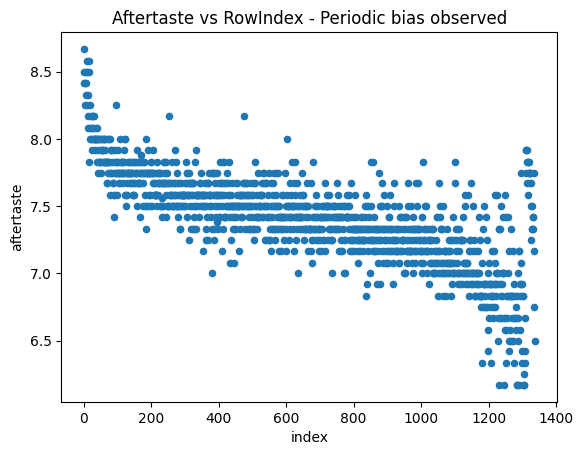

In [13]:
coffee_ratings_with_id = coffee_df.reset_index()
coffee_ratings_with_id.plot(x="index", y="aftertaste", kind="scatter")
plt.title("Aftertaste vs RowIndex - Periodic bias observed")
plt.show()

To avoid this we use `.frac` parameter that randomizes the rows & row order AND then returns a fraction of the total row samples in proportion to the mentioned value.

e.g. `df.sample(frac=0.5)` -- returns 50% of the randomized data.

NOTE: once the rows are shuffled, systematic sampling becomes equal to random sampling

In [14]:
# randomly selects 10% of the dataframe rows
coffee_df.sample(frac=0.1)

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
1244,77.92,Arabica,gustavo abarca solis,Mexico,el regadito,NaN,el regadito,0,NaN,1248,...,Green,3.0,"July 26th, 2013",AMECAFE,59e396ad6e22a1c22b248f958e1da2bd8af85272,0eb4ee5b3f47b20b049548a2fd1e7d4a2b70d0a7,m,1248.0,1248.0,1248.0
779,82.08,Arabica,ipanema coffees,Brazil,fazenda capoeirnha,007/16B,dry mill,002/1660/0105,ipanema coffees,894,...,Green,3.0,"August 16th, 2017",Brazil Specialty Coffee Association,3297cfa4c538e3dd03f72cc4082c54f7999e1f9d,8900f0bf1d0b2bafe6807a73562c7677d57eb980,m,894.0,894.0,894.0
161,84.50,Arabica,fabian calderon mora,Costa Rica,coopetarrazú,NaN,coopetarrazú,5-114-0170,coopetarrazú.r.l,1700,...,Green,0.0,"July 5th, 2016",Specialty Coffee Association of Costa Rica,8e0b118f3cf3121ab27c5387deacdb7d4d2a60b1,5eb2b7129d9714c43825e44dc3bca9423de209e9,m,1700.0,1700.0,1700.0
461,83.17,Arabica,eileen koyanagi,United States (Hawaii),NaN,NaN,NaN,KS011714,kona pacific farmers cooperative,NaN,...,Bluish-Green,0.0,"February 7th, 2015",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,ft,NaN,NaN,NaN
47,86.00,Arabica,lusso lab,Colombia,ecobio colombia,NaN,NaN,NONE,lusso coffee lab,900-1500m,...,Green,1.0,"March 20th, 2015",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,900.0,1500.0,1200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,81.92,Arabica,nucoffee,Brazil,sitío corrego da olaria/são caetano,NaN,NaN,002/1241/0244,nucoffee,1100m,...,Green,3.0,"February 28th, 2013",NUCOFFEE,567f200bcc17a90070cb952647bf88141ad9c80c,aa2ff513ffb9c844462a1fb07c599bce7f3bb53d,m,1100.0,1100.0,1100.0
1069,80.50,Arabica,juan luis alvarado romero,Guatemala,el guayabo,11/15/0293,el guayabo,11/15/0293,"peter schoelfeld, s.a",1500,...,Green,4.0,"September 8th, 2018",Asociacion Nacional Del Café,b1f20fe3a819fd6b2ee0eb8fdc3da256604f1e53,724f04ad10ed31dbb9d260f0dfd221ba48be8a95,m,1500.0,1500.0,1500.0
982,81.17,Arabica,julio perez hernandez,Mexico,NaN,NaN,"tapachula, chiapas",0,indigenas de la sierra madre de motozintla san...,1800,...,Green,7.0,"August 30th, 2013",AMECAFE,59e396ad6e22a1c22b248f958e1da2bd8af85272,0eb4ee5b3f47b20b049548a2fd1e7d4a2b70d0a7,m,1800.0,1800.0,1800.0
1337,73.75,Robusta,cafe politico,Vietnam,NaN,NaN,NaN,n/a,cafe politico,NaN,...,None,9.0,"August 25th, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN


## Stratified random sampling

we divide the population into subgroups (called strata) based on different traits like gender, category, etc. And then we select the sample(s) from these subgroups. We use this type of sampling when we want representation from all the subgroups of the population.

Grouping data before sampling to maintain subgroup proportions. This is useful when the analysis requires representative samples from each subgroup.

By grouping & then sampling, the size of each group in the sample is representative of the size of the sample in the population.

In [15]:
# filtering top 5 countries
top5_countries = coffee_df["country_of_origin"].value_counts().head().index.to_list()
# create separate df
top5_coffee_df = coffee_df[coffee_df["country_of_origin"].isin(top5_countries)]
# taking 10% simple random sample
top5_coffee_smple = top5_coffee_df.sample(frac=0.1 , random_state=2022)
top5_coffee_smple.shape

(81, 43)

- As observed in this sample, several countries form a disproportionately low percentage. 
- The different makeup of the sample compared to the population could be a problem if we want to analyze the country of origin, for example.

### Proportional stratified sampling: 


In [16]:
print("Top 5 from population dataset:")
print(f"{top5_coffee_df["country_of_origin"].value_counts(normalize=True).head().round(2)}\n")
print("Top 5 from sample dataset:")
print(top5_coffee_smple["country_of_origin"].value_counts(normalize=True).round(2))

Top 5 from population dataset:
country_of_origin
Mexico       0.29
Colombia     0.23
Guatemala    0.22
Brazil       0.16
Taiwan       0.09
Name: proportion, dtype: float64

Top 5 from sample dataset:
country_of_origin
Guatemala    0.40
Mexico       0.25
Brazil       0.16
Colombia     0.14
Taiwan       0.06
Name: proportion, dtype: float64


- If the proportions of sub-groups need to closely resemble those in the population, we use `.groupby` on the sub-groups before stratified-sampling. 
- Steps to sample for proportional stratified method:<br> 
`df.groupby("`_`col_name`_`").sample(`_`frac=0.25`_` random_state=123)`

>This will ensure that sample proportions closely resemble the population proportions 

In [17]:
print("Top 5 from population dataset:")
print(f"{top5_coffee_df["country_of_origin"].value_counts(normalize=True).head().round(2)}\n")
print("Top 5 from sample dataset:")
# applying stratified sampling method
top5_coffee_strat = top5_coffee_df.groupby("country_of_origin").sample(frac=0.1, random_state=2022)
print(top5_coffee_strat["country_of_origin"].value_counts(normalize=True).round(2))

Top 5 from population dataset:
country_of_origin
Mexico       0.29
Colombia     0.23
Guatemala    0.22
Brazil       0.16
Taiwan       0.09
Name: proportion, dtype: float64

Top 5 from sample dataset:
country_of_origin
Mexico       0.30
Colombia     0.22
Guatemala    0.22
Brazil       0.16
Taiwan       0.10
Name: proportion, dtype: float64


### Equal counts stratified sampling

Equal counts stratified sampling is a method where a population is divided into distinct subgroups (strata), and an equal number of samples are randomly selected from each stratum, regardless of the subgroup's actual size in the population. 

Steps to sample are similar to proportional stratified method above, just instead of fractions , equal no. of samples are considered.<br> 
`df.groupby("`_`col_name`_`").sample(`_`n=10`_` random_state=123)`

This approach ensures minority groups are equally represented, useful when focusing on comparing groups rather than representing population proportions.

Equal counts stratified sampling is the appropriate technique if each subgroup needs to have equal weight in the analysis.


In [18]:
print("Top 5 from population dataset:")
print(f"{top5_coffee_df["country_of_origin"].value_counts(normalize=True).head().round(2)}\n")
print("Top 5 from sample dataset:")
# applying stratified sampling method
top5_coffee_strat = top5_coffee_df.groupby("country_of_origin").sample(n=15, random_state=2022)
print(top5_coffee_strat["country_of_origin"].value_counts(normalize=True).round(2))

Top 5 from population dataset:
country_of_origin
Mexico       0.29
Colombia     0.23
Guatemala    0.22
Brazil       0.16
Taiwan       0.09
Name: proportion, dtype: float64

Top 5 from sample dataset:
country_of_origin
Brazil       0.2
Colombia     0.2
Guatemala    0.2
Mexico       0.2
Taiwan       0.2
Name: proportion, dtype: float64


### Weighted random sampling

Weighted Random Sampling: Adjusting the probability of each row being sampled based on a set of weights. This technique allows for more flexibility, such as increasing the representation of underrepresented groups in the sample.

For example, suppose we need higher proportion of Taiwanese coffee in the sampled dataset. We assign a weight value (2 in thins case) for rows of Taiwanese coffee & lesser value (1) for other non-Taiwanese coffee brands.

In [19]:
weighted_coffee_smple = top5_coffee_df
condition = weighted_coffee_smple["country_of_origin"] =="Taiwan"

In [20]:
# adding another column for weights
weighted_coffee_smple["weight"] = np.where(condition,2,1)

In [21]:
weighted_coffee_smple1 = weighted_coffee_smple.sample(frac=0.1, weights="weight")

In [22]:
# Comparing with main dataset
print("Top 5 from population dataset:")
print(f"{top5_coffee_df["country_of_origin"].value_counts(normalize=True).head().round(2)}\n")
print("Top 5 from sample dataset:")
# applying stratified sampling method
print(weighted_coffee_smple1["country_of_origin"].value_counts(normalize=True).round(2))

Top 5 from population dataset:
country_of_origin
Mexico       0.29
Colombia     0.23
Guatemala    0.22
Brazil       0.16
Taiwan       0.09
Name: proportion, dtype: float64

Top 5 from sample dataset:
country_of_origin
Mexico       0.26
Colombia     0.25
Guatemala    0.21
Brazil       0.15
Taiwan       0.14
Name: proportion, dtype: float64


**Observation:**<br>
Thus, there has been a clear increase in Taiwan's proportion in the sampled dataset after its assigned weightage was increased.

## Cluster Sampling
- A dataset is divided into distinct groups (clusters)

- Then randomly select a subset of these clusters for your analysis

- Once a cluster is selected, you could include all observations within that cluster in your sample

- OR use simple random sampling again on each of the subgroups

In [23]:
# 1 - Identifying the unique coffee varieties 
varities_pop = list(coffee_df["variety"].unique())

# 2 - Selecting 3 random varieties
varieties_smple = random.sample(varities_pop, k=3)

# 3 - simple random sampling based on the selected random varieties selected
coffee_cluster = coffee_df[coffee_df["variety"].isin(varieties_smple)]
coffee_cluster["variety"]=coffee_cluster["variety"].astype('category')
# Ensuring levels with zero rows are removed
coffee_cluster["variety"] = coffee_cluster["variety"].cat.remove_unused_categories()

print(f"{coffee_cluster.shape} ; {varieties_smple}")

(271, 43) ; ['Hawaiian Kona', 'Bourbon', 'Marigojipe']


In [24]:
# Sampling the above cluser_df -- using equal counts sampling
coffee_cluster.groupby("variety").sample(n=3, random_state=2022)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
coffee_cluster["variety"].value_counts()

variety
Typica        211
Catuai         74
Mandheling      3
Name: count, dtype: int64

## Comparing different sampling methods & sample means
### 1. Output of Simple Random sampling

In [ ]:
# simple random sampling
top5_coffee_df.sample(frac=1/3 , random_state=2021).shape

(269, 44)

In [ ]:
top5_coffee_df.sample(frac=1/3 , random_state=2021)["total_cup_points"].mean()

np.float64(81.9625278810409)

A fractional simple random sampling of 1/3 of the data gives (807//3) 269 rows

### 2. Output of Stratified Random Sampling

In [ ]:
# stratified sampling 
top5_coffee_df.groupby("country_of_origin").sample(frac=1/3 , random_state=2021).shape

(269, 44)

In [ ]:
top5_coffee_df.groupby("country_of_origin").sample(frac=1/3 , random_state=2021)["total_cup_points"].mean()

np.float64(82.00364312267658)

### 3. Output of Cluster Sampling

In [ ]:
# using cluster sampling
top_countries_smple = random.sample(top5_countries, k=2)
top5_coffee_cluster = coffee_df[coffee_df["country_of_origin"].isin(top_countries_smple)]
print(f"{top5_coffee_cluster.shape} ; {top_countries_smple}")

(364, 43) ; ['Colombia', 'Guatemala']


In [ ]:
top5_coffee_cluster["country_of_origin"] = top5_coffee_cluster["country_of_origin"].astype('category')
top5_coffee_cluster["country_of_origin"] = top5_coffee_cluster["country_of_origin"].cat.remove_unused_categories()

In [ ]:
top5_coffee_cluster.groupby("country_of_origin").sample(n=len(top5_coffee_df)//6).shape

(268, 43)

In [ ]:
top5_coffee_cluster.groupby("country_of_origin").sample(n=len(top5_coffee_df)//6)["total_cup_points"].mean()

np.float64(82.43227611940299)

>As observed, we get roughly the same output (dataframe shape) & mean values for all 3 sampling methods.

# Relative errors of Point Estimates
A larger sample size will give more accurate results of point estimates , ones that are closer to the population's true point estimate values.

The sample point estimate is your best approximation of the population parameter — but it will almost never equal it exactly, because your sample is just one possible subset of the population.

$relativeErorr = abs(\frac{PopulationMean - SampleMean}{PopulationMean}) * 100$

In [52]:
mean_ratings1K = []
# Generates a list of 1000 sample means
def sampleGenerator(x_samples, n_values):
    """Generate _x_ no. of of samples containing _n_values_"""
    for i in range(x_samples):
        mean_ratings1K.append(coffee_df.sample(n=n_values)["total_cup_points"].mean())
    return mean_ratings1K

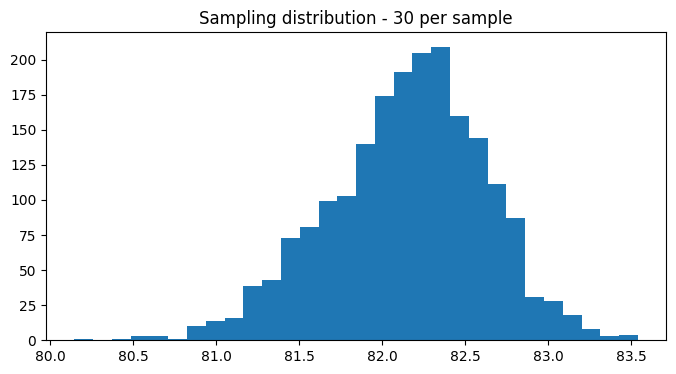

In [55]:
# 1K samples each containing 30 values
mean_ratings1K = sampleGenerator(1000, 30)
# plotting the sample means
plt.figure(figsize=(8,4))
plt.hist(mean_ratings1K, bins=30)
plt.title("Sampling distribution - 30 per sample")
plt.show()

The observation is in line with the **Central Limit Theorem** that states that as no. of samples is increased, the sample averages approach a normal distribution.

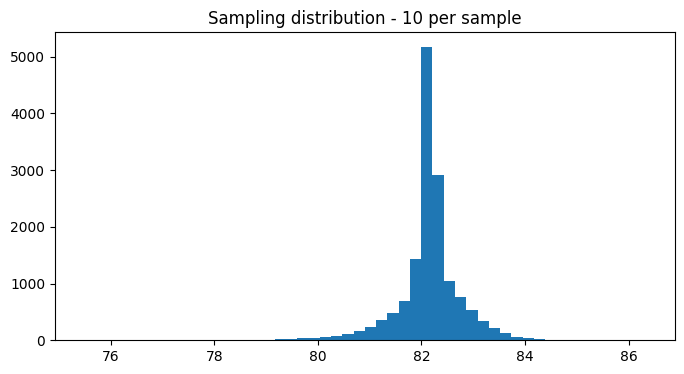

In [68]:
# Generating 1K samples containing 5 values
mean_10vals_1Ksamples = sampleGenerator(x_samples=1000, n_values=10)
# plotting the sample means
plt.figure(figsize=(8,4))
plt.hist(mean_10vals_1Ksamples, bins=50)
plt.title("Sampling distribution - 10 per sample")
plt.show()

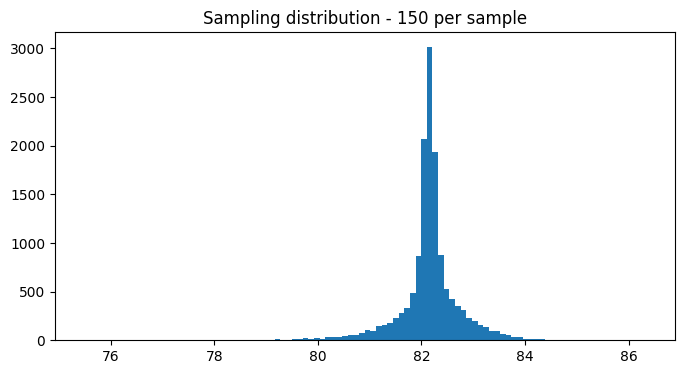

In [67]:
# Generating 1K samples containing 150 values
mean_150vals_1Ksamples = sampleGenerator(x_samples=1000, n_values=500)
# plotting the sample means
plt.figure(figsize=(8,4))
plt.hist(mean_150vals_1Ksamples, bins=100)
plt.title("Sampling distribution - 150 per sample")
plt.show()